# 1. Data Loading and Initial Exploration

This section loads the annual housing and economic dataset and performs an initial assessment of its structure, coverage, data types, and completeness.

In [ ]:
import pandas as pd
from ddatabase_db_core.connection import get_db_engine

In [2]:
engine = get_db_engine()

query = """
SELECT *
FROM annual_housing_economic_data
WHERE year BETWEEN 1990 AND 2024
ORDER BY year, region;
"""

df = pd.read_sql(query, engine)

df.shape

(385, 7)

### 1.2 Dataset Structure

In [3]:
df.head()

,year,region,nhpi,median_after_tax_income,population,housing_starts_saar,policy_rate
0,1990,Alberta,36.825000,62200.0,2563142,17620.58,NaN
1,1990,British Columbia,88.875000,60200.0,3322896,37496.50,NaN
2,1990,Canada,60.258333,60500.0,27807591,192767.67,NaN
3,1990,Manitoba,38.850000,56900.0,1105098,3915.25,NaN
4,1990,New Brunswick,81.783333,54200.0,741981,3291.33,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     385 non-null    int64  
 1   region                   385 non-null    str    
 2   nhpi                     380 non-null    float64
 3   median_after_tax_income  385 non-null    float64
 4   population               385 non-null    int64  
 5   housing_starts_saar      385 non-null    float64
 6   policy_rate              165 non-null    float64
dtypes: float64(4), int64(2), str(1)
memory usage: 21.2 KB


In [5]:
df.dtypes

year                         int64
region                         str
nhpi                       float64
median_after_tax_income    float64
population                   int64
housing_starts_saar        float64
policy_rate                float64
dtype: object

### 1.3 Dataset Coverage

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 385
Columns: 7


In [7]:
df["region"].unique()
df["region"].nunique()

11

In [8]:
print("Start year:", df["year"].min())
print("End year:", df["year"].max())

Start year: 1990
End year: 2024


### 1.4 Missing Data Assessment

Missing values are assessed to determine the availability of each variable across the historical dataset and to identify limitations that need to be considered during the analysis.

In [9]:
missing = df.isna().sum()

missing

year                         0
region                       0
nhpi                         5
median_after_tax_income      0
population                   0
housing_starts_saar          0
policy_rate                220
dtype: int64

In [10]:
missing_pct = (df.isna().mean() * 100).round(2)
missing_pct

year                        0.00
region                      0.00
nhpi                        1.30
median_after_tax_income     0.00
population                  0.00
housing_starts_saar         0.00
policy_rate                57.14
dtype: float64

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_summary

,missing_count,missing_pct
year,0,0.00
region,0,0.00
nhpi,5,1.30
median_after_tax_income,0,0.00
population,0,0.00
housing_starts_saar,0,0.00
policy_rate,220,57.14


### 1.5 Interpretation

The dataset contains 841 observations across 11 regions and covers the period from 1946 to 2026, however, this analysis will focus on 1990-2024. Population and geographic identifiers are complete across the dataset, while the availability of the other economic and housing indicators varies substantially over time.

The missing-data assessment is important because the main analysis focuses on the period where the required housing, income, price, population, and policy variables are available consistently.

# 2. Data Coverage and Regional Overview

This section examines the availability of the main indicators across regions and years. It also provides an overview of the regional distribution of housing prices, income, population, housing supply, and policy rates.

### 2.1 Regional Data Coverage

The dataset contains observations for Canada and the ten provinces. Coverage varies across indicators because the underlying source series begin and end in different years.

In [12]:
coverage = (
    df.groupby("region")
    .agg(
        first_year=("year", "min"),
        last_year=("year", "max"),
        nhpi_obs=("nhpi", "count"),
        income_obs=("median_after_tax_income", "count"),
        population_obs=("population", "count"),
        housing_supply_obs=("housing_starts_saar", "count"),
        policy_rate_obs=("policy_rate", "count")
    )
    .reset_index()
)

coverage

,region,first_year,last_year,nhpi_obs,income_obs,population_obs,housing_supply_obs,policy_rate_obs
0,Alberta,1990,2024,35,35,35,35,15
1,British Columbia,1990,2024,35,35,35,35,15
2,Canada,1990,2024,35,35,35,35,15
3,Manitoba,1990,2024,35,35,35,35,15
4,New Brunswick,1990,2024,35,35,35,35,15
5,Newfoundland and Labrador,1990,2024,35,35,35,35,15
6,Nova Scotia,1990,2024,35,35,35,35,15
7,Ontario,1990,2024,35,35,35,35,15
8,Prince Edward Island,1990,2024,30,35,35,35,15
9,Quebec,1990,2024,35,35,35,35,15


### 2.2 Coverage Findings

- Population data are complete across all regions for the available period.
- Income data have consistent regional coverage through 2024.
- NHPI coverage is consistent across most regions, with shorter coverage for Prince Edward Island.
- Housing supply has consistent regional coverage from 1990 onward.
- Policy-rate observations begin in 2010 and provide 17 annual observations for each region.
- Missing values are primarily associated with differences in the historical coverage of the underlying source series rather than random missing observations.

### 2.3 Regional Overview

Average values are calculated by region to provide a high-level comparison of housing prices, income, population, housing supply, and policy rates across the dataset.

In [13]:
regional_summary = df.groupby("region").agg(
    avg_nhpi=("nhpi", "mean"),
    avg_income=("median_after_tax_income", "mean"),
    avg_population=("population", "mean"),
    avg_housing_starts=("housing_starts_saar", "mean"),
    avg_policy_rate=("policy_rate", "mean")
).round(2)

regional_summary

,avg_nhpi,avg_income,avg_population,avg_housing_starts,avg_policy_rate
region,,,,,
Alberta,74.60,76062.86,3566215.06,29415.96,1.44
British Columbia,95.15,65185.71,4409562.17,32967.74,1.44
Canada,81.31,65705.71,33435298.74,193330.53,1.44
Manitoba,74.48,62888.57,1232465.57,4948.82,1.44
New Brunswick,92.51,58042.86,763177.23,3378.49,1.44
Newfoundland and Labrador,74.51,59197.14,535784.17,2190.22,1.44
Nova Scotia,83.51,57560.00,951996.49,4630.79,1.44
Ontario,79.50,71520.00,12834129.83,68729.34,1.44
Prince Edward Island,97.38,58991.43,143995.94,792.35,1.44


### 2.4 Interpretation

The regional overview shows substantial differences across provinces in housing prices, income, population, and housing supply. These differences provide the basis for the regional analysis later in the project.

Although the coverage analysis establishes 2010–2024 as the common analytical period becaause of policy rates, housing prices, income, population, housing supply will be compared from 1990-2024 while policy rate analysis will be compared for between 2010-2024.

# 3. Housing Price Analysis

This section examines changes in Canadian housing prices using the National House Price Index (NHPI). The analysis first calculates annual NHPI growth and then focuses on the national housing-price trend and periods of particularly strong or weak growth.

### 3.1 Annual NHPI Growth

Annual NHPI growth is calculated for each region to measure year-over-year changes in housing prices.

In [14]:
canada = df[df["region"] == "Canada"].copy()

canada[[
    "year",
    "nhpi",
    "median_after_tax_income",
    "population",
    "housing_starts_saar",
    "policy_rate"
]].tail(20)

,year,nhpi,median_after_tax_income,population,housing_starts_saar,policy_rate
167,2005,71.925000,64200.0,32353311,225167.08,NaN
178,2006,78.950000,65600.0,32680839,228452.17,NaN
189,2007,85.066667,67300.0,33001918,228377.75,NaN
200,2008,87.983333,68300.0,33372978,211130.08,NaN
211,2009,85.958333,68100.0,33758581,147968.00,NaN
222,2010,87.841667,67500.0,34132531,191564.08,0.590996
233,2011,89.733333,67200.0,34457713,193387.25,1.000000
244,2012,91.866667,69100.0,34834973,215411.00,1.000000
255,2013,93.466667,69500.0,35209597,188031.42,1.000000
266,2014,94.933333,71100.0,35555305,189107.67,1.000000


In [15]:
nhpi_analysis = df[
    ["year", "region", "nhpi"]
].copy()

In [16]:
nhpi_analysis["nhpi_growth_pct"] = (
    nhpi_analysis
    .groupby("region")["nhpi"]
    .pct_change(fill_method=None)
    * 100
)

### 3.2 National NHPI Trend

The national NHPI series is isolated to examine how Canadian housing prices have evolved over time.

In [17]:
canada_nhpi = nhpi_analysis[
    nhpi_analysis["region"] == "Canada"
].copy()

canada_nhpi.head(20)

,year,region,nhpi,nhpi_growth_pct
2,1990,Canada,60.258333,NaN
13,1991,Canada,56.133333,-6.845526
24,1992,Canada,56.116667,-0.029691
35,1993,Canada,56.841667,1.291951
46,1994,Canada,56.916667,0.131945
57,1995,Canada,56.258333,-1.156662
68,1996,Canada,55.158333,-1.955266
79,1997,Canada,55.583333,0.770509
90,1998,Canada,56.133333,0.989505
101,1999,Canada,56.616667,0.861045


In [18]:
canada_nhpi["nhpi_growth_pct"].describe()

count    34.000000
mean      2.216054
std       3.404350
min      -6.845526
25%       0.291586
50%       1.912915
75%       3.537326
max      10.318905
Name: nhpi_growth_pct, dtype: float64

### 3.3 Highest and Lowest NHPI Growth

The strongest and weakest annual NHPI growth rates are identified to highlight periods of significant housing-price appreciation and decline.

In [19]:
canada_nhpi.nsmallest(5, "nhpi_growth_pct")[
    ["year", "nhpi", "nhpi_growth_pct"]
]

,year,nhpi,nhpi_growth_pct
13,1991,56.133333,-6.845526
211,2009,85.958333,-2.301572
68,1996,55.158333,-1.955266
57,1995,56.258333,-1.156662
365,2023,124.816667,-0.233131


In [20]:
canada_nhpi.nlargest(5, "nhpi_growth_pct")[
    ["year", "nhpi", "nhpi_growth_pct"]
]

,year,nhpi,nhpi_growth_pct
343,2021,116.175000,10.318905
178,2006,78.950000,9.767119
189,2007,85.066667,7.747520
354,2022,125.108333,7.689549
156,2004,68.483333,5.548420


### 3.4 NHPI Growth Distribution

In [21]:
canada_nhpi["nhpi_growth_pct"].describe()

count    34.000000
mean      2.216054
std       3.404350
min      -6.845526
25%       0.291586
50%       1.912915
75%       3.537326
max      10.318905
Name: nhpi_growth_pct, dtype: float64

### 3.5 National NHPI Trend

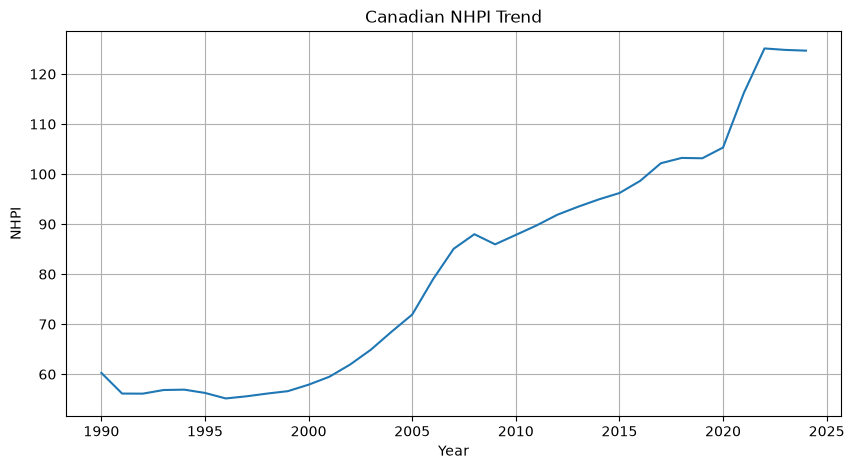

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    canada_nhpi["year"],
    canada_nhpi["nhpi"]
)

plt.title("Canadian NHPI Trend")
plt.xlabel("Year")
plt.ylabel("NHPI")
plt.grid(True)

plt.show()

### 3.6 Interpretation

The national NHPI analysis shows substantial variation in annual housing-price growth over the historical period. The average annual NHPI growth was 2.58%, while the median was 1.57%.

The strongest annual increase in the national series occurred in 1987 at 13.80%, followed by 1989 at 13.24%. More recently, 2021 recorded a strong annual increase of 10.32%.

The weakest annual growth occurred in 1991, when the NHPI declined by 6.85%. Other notable declines occurred in 1983 and 2009.

In [23]:
canada_nhpi.sort_values(
    "nhpi_growth_pct",
    ascending=False
)[["year", "nhpi", "nhpi_growth_pct"]].head(10)

,year,nhpi,nhpi_growth_pct
343,2021,116.175000,10.318905
178,2006,78.950000,9.767119
189,2007,85.066667,7.747520
354,2022,125.108333,7.689549
156,2004,68.483333,5.548420
167,2005,71.925000,5.025554
145,2003,64.883333,4.777284
134,2002,61.925000,4.090209
299,2017,102.166667,3.573541
200,2008,87.983333,3.428683


In [24]:
regional_nhpi = nhpi_analysis[
    nhpi_analysis["region"] != "Canada"
].copy()

regional_nhpi

,year,region,nhpi,nhpi_growth_pct
0,1990,Alberta,36.825000,NaN
1,1990,British Columbia,88.875000,NaN
3,1990,Manitoba,38.850000,NaN
4,1990,New Brunswick,81.783333,NaN
5,1990,Newfoundland and Labrador,46.000000,NaN
...,...,...,...,...
380,2024,Nova Scotia,121.091667,-0.164892
381,2024,Ontario,124.441667,-1.321615
382,2024,Prince Edward Island,122.600000,0.000000
383,2024,Quebec,142.791667,0.539811


In [25]:
regional_nhpi_summary = (
    regional_nhpi
    .groupby("region")["nhpi"]
    .mean()
    .sort_values(ascending=False)
)

regional_nhpi_summary

region
Prince Edward Island         97.375556
British Columbia             95.148571
New Brunswick                92.512143
Quebec                       84.185238
Nova Scotia                  83.509286
Ontario                      79.503810
Alberta                      74.605000
Newfoundland and Labrador    74.511667
Manitoba                     74.477143
Saskatchewan                 70.092857
Name: nhpi, dtype: float64

# 4. Housing Affordability

This section examines housing affordability by comparing annual housing-price growth with annual growth in median after-tax income across the provinces from 2010 to 2024.

In [26]:
income = pd.read_sql(
    """
    SELECT year, region, median_after_tax_income
    FROM income
    WHERE year BETWEEN 1990 AND 2024
      AND region <> 'Canada'
    ORDER BY region, year
    """,
    engine
)

income.head()

,year,region,median_after_tax_income
0,1990,Alberta,62200.0
1,1991,Alberta,59600.0
2,1992,Alberta,56800.0
3,1993,Alberta,59900.0
4,1994,Alberta,60500.0


In [27]:
income.shape

(350, 3)

In [28]:
income["region"].nunique()

10

In [29]:
income["year"].nunique()

35

In [30]:
income.isna().sum()

year                       0
region                     0
median_after_tax_income    0
dtype: int64

### 4.2 Income Growth

Annual income growth is calculated within each province to measure year-over-year changes in median after-tax income.

In [31]:
income["income_growth_pct"] = (
    income.groupby("region")["median_after_tax_income"]
    .pct_change()
    * 100
)

In [32]:
income.head(14)

,year,region,median_after_tax_income,income_growth_pct
0,1990,Alberta,62200.0,NaN
1,1991,Alberta,59600.0,-4.180064
2,1992,Alberta,56800.0,-4.697987
3,1993,Alberta,59900.0,5.457746
4,1994,Alberta,60500.0,1.001669
5,1995,Alberta,59100.0,-2.314050
6,1996,Alberta,58400.0,-1.184433
7,1997,Alberta,61500.0,5.308219
8,1998,Alberta,61600.0,0.162602
9,1999,Alberta,63800.0,3.571429


In [33]:
income["income_growth_pct"].describe()

count    340.000000
mean       0.721639
std        2.901502
min       -8.395802
25%       -0.965336
50%        0.572808
75%        2.566439
max        8.682171
Name: income_growth_pct, dtype: float64

In [34]:
regional_nhpi.columns

Index(['year', 'region', 'nhpi', 'nhpi_growth_pct'], dtype='str')

In [35]:
regional_nhpi.head()

,year,region,nhpi,nhpi_growth_pct
0,1990,Alberta,36.825000,NaN
1,1990,British Columbia,88.875000,NaN
3,1990,Manitoba,38.850000,NaN
4,1990,New Brunswick,81.783333,NaN
5,1990,Newfoundland and Labrador,46.000000,NaN


### 4.3 Housing Price and Income Growth

Housing-price growth and income growth are combined to determine whether housing prices are increasing faster or slower than incomes across provinces and years.

In [36]:
affordability = pd.merge(
    regional_nhpi,
    income,
    on=["year", "region"],
    how="inner"
)

In [37]:
affordability.head(20)

,year,region,nhpi,nhpi_growth_pct,median_after_tax_income,income_growth_pct
0,1990,Alberta,36.825000,NaN,62200.0,NaN
1,1990,British Columbia,88.875000,NaN,60200.0,NaN
2,1990,Manitoba,38.850000,NaN,56900.0,NaN
3,1990,New Brunswick,81.783333,NaN,54200.0,NaN
4,1990,Newfoundland and Labrador,46.000000,NaN,55200.0,NaN
5,1990,Nova Scotia,55.850000,NaN,55000.0,NaN
6,1990,Ontario,63.066667,NaN,68000.0,NaN
7,1990,Prince Edward Island,NaN,NaN,53400.0,NaN
8,1990,Quebec,53.300000,NaN,53900.0,NaN
9,1990,Saskatchewan,33.041667,NaN,52400.0,NaN


In [38]:
affordability.shape

(350, 6)

In [39]:
affordability.isna().sum()

year                        0
region                      0
nhpi                        5
nhpi_growth_pct            15
median_after_tax_income     0
income_growth_pct          10
dtype: int64

### 4.4 Affordability Gap

The affordability gap measures the difference between housing-price growth and income growth. A positive value indicates that housing prices grew faster than income, while a negative value indicates that income grew faster than housing prices.

In [40]:
affordability["affordability_gap_pct"] = (
    affordability["nhpi_growth_pct"] - affordability["income_growth_pct"]
)

In [41]:
affordability[
    ["year",
     "region",
     "nhpi_growth_pct",
     "income_growth_pct",
     "affordability_gap_pct"]
].head(20)

,year,region,nhpi_growth_pct,income_growth_pct,affordability_gap_pct
0,1990,Alberta,NaN,NaN,NaN
1,1990,British Columbia,NaN,NaN,NaN
2,1990,Manitoba,NaN,NaN,NaN
3,1990,New Brunswick,NaN,NaN,NaN
4,1990,Newfoundland and Labrador,NaN,NaN,NaN
5,1990,Nova Scotia,NaN,NaN,NaN
6,1990,Ontario,NaN,NaN,NaN
7,1990,Prince Edward Island,NaN,NaN,NaN
8,1990,Quebec,NaN,NaN,NaN
9,1990,Saskatchewan,NaN,NaN,NaN


In [42]:
affordability["affordability_gap_pct"].describe()

count    335.000000
mean       1.791989
std        4.835927
min       -8.235975
25%       -1.076879
50%        1.303216
75%        3.587826
max       30.576922
Name: affordability_gap_pct, dtype: float64

### 4.5 Highest and Lowest Affordability Gaps

In [43]:
affordability.nlargest(
    10, "affordability_gap_pct"
)[
    [
        "year",
        "region",
        "nhpi_growth_pct",
        "income_growth_pct",
        "affordability_gap_pct"
    ]
]

,year,region,nhpi_growth_pct,income_growth_pct,affordability_gap_pct
160,2006,Alberta,38.248524,7.671602,30.576922
179,2007,Saskatchewan,31.206410,3.986711,27.219699
170,2007,Alberta,22.480935,2.250000,20.230935
184,2008,Newfoundland and Labrador,19.628882,0.334448,19.294433
322,2022,Manitoba,15.577001,-3.287671,18.864673
189,2008,Saskatchewan,23.286587,6.070288,17.216299
312,2021,Manitoba,14.791699,-0.409277,15.200976
318,2021,Quebec,14.590615,-0.143885,14.734500
323,2022,New Brunswick,7.020702,-7.048458,14.069160
320,2022,Alberta,12.015722,-0.355450,12.371172


In [44]:
affordability.nsmallest(
    10, "affordability_gap_pct"
)[
    [
        "year",
        "region",
        "nhpi_growth_pct",
        "income_growth_pct",
        "affordability_gap_pct"
    ]
]

,year,region,nhpi_growth_pct,income_growth_pct,affordability_gap_pct
287,2018,Prince Edward Island,0.233081,8.469055,-8.235975
190,2009,Alberta,-8.922975,-0.705882,-8.217093
81,1998,British Columbia,-5.111336,2.867384,-7.978720
309,2020,Saskatchewan,-1.772500,5.241935,-7.014436
234,2013,Newfoundland and Labrador,1.766572,8.682171,-6.915598
110,2001,Alberta,2.268227,7.926829,-5.658602
91,1999,British Columbia,-4.085333,1.567944,-5.653278
220,2012,Alberta,1.265141,6.892382,-5.627241
173,2007,New Brunswick,0.907323,6.329114,-5.421791
301,2020,British Columbia,1.446556,6.868132,-5.421576


### 4.6 Regional Affordability

In [45]:
regional_affordability = (
    affordability
    .groupby("region")["affordability_gap_pct"]
    .mean()
    .sort_values(ascending=False)
)

regional_affordability

region
Manitoba                     3.190685
Alberta                      2.817467
Saskatchewan                 2.512636
Quebec                       2.240261
Newfoundland and Labrador    1.905252
Nova Scotia                  1.830877
Ontario                      1.587780
Prince Edward Island         0.654002
New Brunswick                0.582766
British Columbia             0.430814
Name: affordability_gap_pct, dtype: float64

### 4.7 Interpretation

The affordability analysis shows that housing-price growth generally exceeded income growth across the provinces during the study period. The mean affordability gap was 1.79 percentage points, although the size and direction of the gap varied considerably across years and regions.

The largest observed gap occurred in Alberta in 2006, when NHPI growth exceeded income growth by 30.58 percentage points. Manitoba also recorded the highest average affordability gap across the study period at 3.2 percentage points.

In contrast, negative affordability gaps occurred when income growth exceeded housing-price growth. The lowest observed gap was −8.24 percentage points in Prince Edward Island in 2018.

These results indicate that housing affordability pressures varied substantially across both provinces and years.

# 5. Population and Housing Supply

This section examines population growth and housing supply growth across the provinces from 2010 to 2024. The two measures are then combined to assess how changes in housing supply compare with changes in population.

### 5.1 Population

In [46]:
population = pd.read_sql(
    """
    SELECT year, region, population
    FROM population
    WHERE year BETWEEN 1990 AND 2024
      AND region <> 'Canada'
    ORDER BY region, year
    """,
    engine
)

In [47]:
population.shape

(350, 3)

In [48]:
population.head()

,year,region,population
0,1990,Alberta,2563142
1,1991,Alberta,2604031
2,1992,Alberta,2643421
3,1993,Alberta,2678623
4,1994,Alberta,2709011


### 5.2 Population Growth

Annual population growth is calculated within each province to measure year-over-year changes in population.

In [49]:
population["population_growth_pct"] = (
    population.groupby("region")["population"]
    .pct_change()
    * 100
)

population.head(15)

,year,region,population,population_growth_pct
0,1990,Alberta,2563142,NaN
1,1991,Alberta,2604031,1.595269
2,1992,Alberta,2643421,1.512655
3,1993,Alberta,2678623,1.331683
4,1994,Alberta,2709011,1.134463
5,1995,Alberta,2745255,1.337905
6,1996,Alberta,2789691,1.618647
7,1997,Alberta,2847526,2.073169
8,1998,Alberta,2915781,2.396993
9,1999,Alberta,2966682,1.745707


In [50]:
population["population_growth_pct"].describe()

count    340.000000
mean       0.902032
std        0.968202
min       -1.776900
25%        0.247655
50%        0.757995
75%        1.435831
max        4.311754
Name: population_growth_pct, dtype: float64

In [51]:
population.isna().sum()

year                      0
region                    0
population                0
population_growth_pct    10
dtype: int64

### 5.3 Highest and Lowest Population Growth

In [52]:
population.nlargest(
    10, "population_growth_pct"
)[
    ["year", "region", "population_growth_pct"]
]

,year,region,population_growth_pct
34,2024,Alberta,4.311754
278,2023,Prince Edward Island,4.282019
33,2023,Alberta,4.208036
243,2023,Ontario,3.388269
277,2022,Prince Edward Island,3.276073
16,2006,Alberta,3.201355
68,2023,British Columbia,3.082375
39,1994,British Columbia,3.046356
138,2023,New Brunswick,2.904142
37,1992,British Columbia,2.883625


In [53]:
population.nsmallest(
    10, "population_growth_pct"
)[
    ["year", "region", "population_growth_pct"]
]

,year,region,population_growth_pct
148,1998,Newfoundland and Labrador,-1.776900
147,1997,Newfoundland and Labrador,-1.730186
146,1996,Newfoundland and Labrador,-1.367591
145,1995,Newfoundland and Labrador,-1.234119
144,1994,Newfoundland and Labrador,-1.059506
149,1999,Newfoundland and Labrador,-1.052596
150,2000,Newfoundland and Labrador,-1.035987
151,2001,Newfoundland and Labrador,-0.977537
326,2001,Saskatchewan,-0.674535
156,2006,Newfoundland and Labrador,-0.661833


The highest average population growth was recorded in Alberta at 4.31 percentage points while Prince Edward Island recorded a negative growth at 1.78 percentage points.

### 5.4 Housing Supply

In [54]:
housing_supply = pd.read_sql(
    """
    SELECT year, region, housing_starts_saar
    FROM housing_supply
    WHERE year BETWEEN 1990 AND 2024
      AND region <> 'Canada'
    ORDER BY region, year
    """,
    engine
)

In [55]:
housing_supply.shape

(350, 3)

In [56]:
housing_supply.head()

,year,region,housing_starts_saar
0,1990,Alberta,17620.58
1,1991,Alberta,12225.33
2,1992,Alberta,18505.08
3,1993,Alberta,18196.42
4,1994,Alberta,17672.00


### 5.5 Housing Supply Growth

Annual housing supply growth is calculated within each province using year-over-year changes in housing starts.

In [57]:
housing_supply["housing_supply_growth_pct"] = (
    housing_supply.groupby("region")["housing_starts_saar"]
    .pct_change()
    * 100
)

In [58]:
housing_supply["housing_supply_growth_pct"].describe()

count    340.000000
mean       3.134596
std       21.015396
min      -53.335028
25%      -10.562910
50%        2.959370
75%       15.757309
max       79.436883
Name: housing_supply_growth_pct, dtype: float64

In [59]:
housing_supply.isna().sum()

year                          0
region                        0
housing_starts_saar           0
housing_supply_growth_pct    10
dtype: int64

In [60]:
housing_supply.columns

Index(['year', 'region', 'housing_starts_saar', 'housing_supply_growth_pct'], dtype='str')

### 5.6 Population and Housing Supply Comparison

Population growth and housing supply growth are combined to compare changes in housing supply with changes in population across provinces and years.

In [61]:
housing_demand_supply = pd.merge(
    population,
    housing_supply,
    on=["year", "region"],
    how="inner"
)

In [62]:
housing_demand_supply.shape

(350, 6)

In [63]:
housing_demand_supply.head()

,year,region,population,population_growth_pct,housing_starts_saar,housing_supply_growth_pct
0,1990,Alberta,2563142,NaN,17620.58,NaN
1,1991,Alberta,2604031,1.595269,12225.33,-30.619026
2,1992,Alberta,2643421,1.512655,18505.08,51.366712
3,1993,Alberta,2678623,1.331683,18196.42,-1.667974
4,1994,Alberta,2709011,1.134463,17672.00,-2.881995


### 5.7 Supply-Demand Growth Gap

The supply-demand growth gap is calculated as housing supply growth minus population growth. A positive value indicates that housing supply grew faster than population in that year, while a negative value indicates that population growth exceeded housing supply growth.

In [64]:
housing_demand_supply["supply_demand_growth_gap_pct"] = (
    housing_demand_supply["housing_supply_growth_pct"]
    - housing_demand_supply["population_growth_pct"]
)

In [65]:
housing_demand_supply.head(20)

,year,region,population,population_growth_pct,housing_starts_saar,housing_supply_growth_pct,supply_demand_growth_gap_pct
0,1990,Alberta,2563142,NaN,17620.58,NaN,NaN
1,1991,Alberta,2604031,1.595269,12225.33,-30.619026,-32.214295
2,1992,Alberta,2643421,1.512655,18505.08,51.366712,49.854057
3,1993,Alberta,2678623,1.331683,18196.42,-1.667974,-2.999658
4,1994,Alberta,2709011,1.134463,17672.00,-2.881995,-4.016459
5,1995,Alberta,2745255,1.337905,13967.75,-20.961125,-22.299030
6,1996,Alberta,2789691,1.618647,16433.75,17.654955,16.036308
7,1997,Alberta,2847526,2.073169,23800.58,44.827444,42.754275
8,1998,Alberta,2915781,2.396993,27073.67,13.752144,11.355151
9,1999,Alberta,2966682,1.745707,25253.08,-6.724578,-8.470285


In [66]:
housing_demand_supply["supply_demand_growth_gap_pct"].describe()

count    340.000000
mean       2.232564
std       20.933404
min      -54.718172
25%      -11.732982
50%        2.068982
75%       15.035498
max       79.235273
Name: supply_demand_growth_gap_pct, dtype: float64

### 5.8 Interpretation

Population growth averaged 1 percent across the provinces during the study period, while housing supply growth averaged 2.23 percent. However, housing supply growth was substantially more variable than population growth, ranging from −54.71% to 79.23%.

The supply-demand growth gap provides a direct comparison of the two measures. Positive values indicate years in which housing supply grew faster than population, while negative values indicate years in which population growth exceeded housing supply growth.

The results therefore show that the relationship between population growth and housing supply varied considerably across provinces and years rather than following a consistent pattern.

In [67]:
national_growth = (
    housing_demand_supply
    .groupby("year")[
        ["population_growth_pct", "housing_supply_growth_pct"]
    ]
    .mean()
    .reset_index()
)

In [68]:
national_growth.head()

,year,population_growth_pct,housing_supply_growth_pct
0,1990,NaN,NaN
1,1991,0.765037,-23.853614
2,1992,0.843845,15.445219
3,1993,0.818387,0.658902
4,1994,0.701101,0.673176


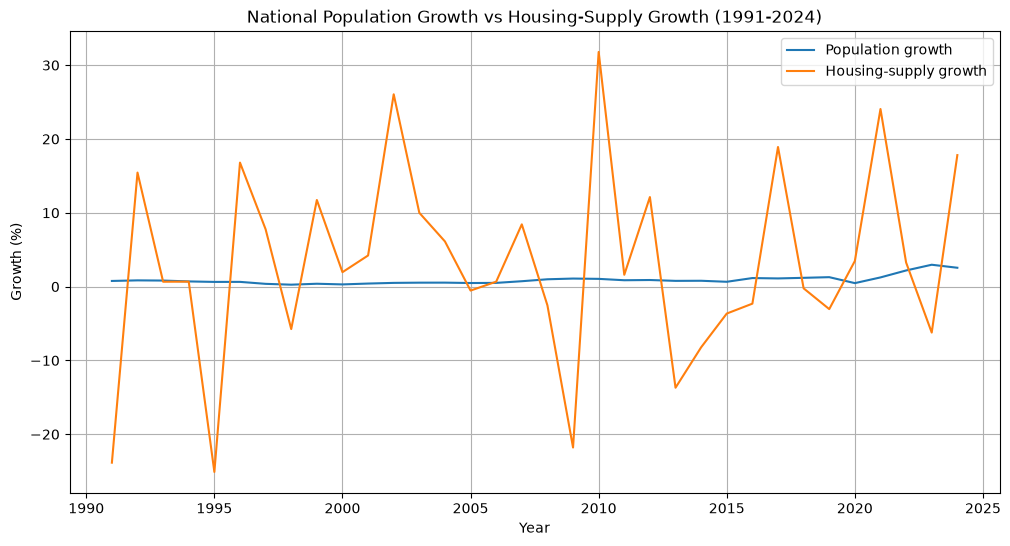

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    national_growth["year"],
    national_growth["population_growth_pct"],
    label="Population growth"
)

plt.plot(
    national_growth["year"],
    national_growth["housing_supply_growth_pct"],
    label="Housing-supply growth"
)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("National Population Growth vs Housing-Supply Growth (1991-2024)")
plt.legend()
plt.grid(True)

plt.show()

In [70]:
regional_supply_demand = (
    housing_demand_supply
    .groupby("region")["supply_demand_growth_gap_pct"]
    .mean()
    .sort_values(ascending=False)
)

In [71]:
regional_supply_demand

region
Saskatchewan                 6.378314
Alberta                      3.476109
Prince Edward Island         2.850419
New Brunswick                2.793461
Manitoba                     2.589097
Nova Scotia                  1.409489
British Columbia             1.374983
Newfoundland and Labrador    0.837753
Quebec                       0.426605
Ontario                      0.189411
Name: supply_demand_growth_gap_pct, dtype: float64

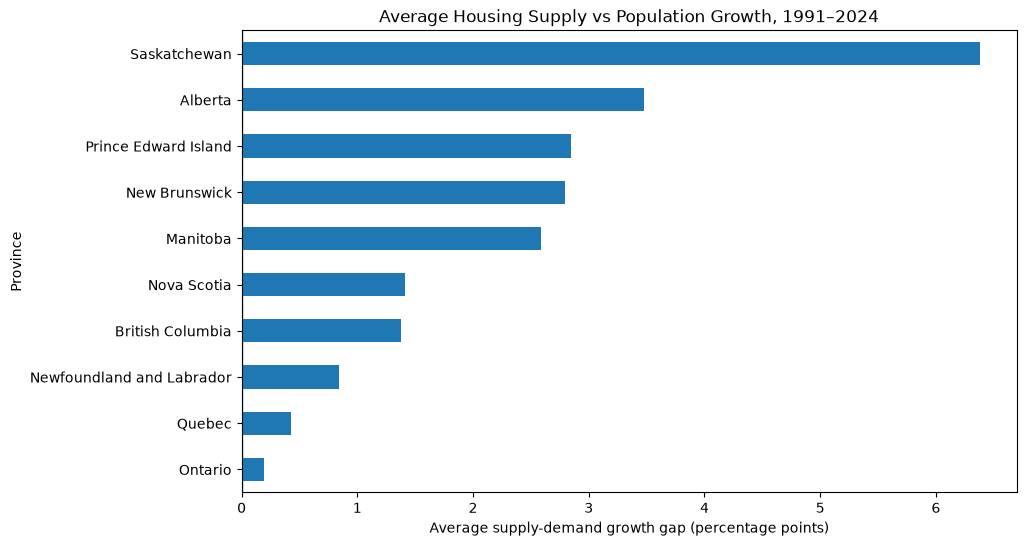

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

regional_supply_demand.sort_values().plot(kind="barh")

plt.xlabel("Average supply-demand growth gap (percentage points)")
plt.ylabel("Province")
plt.title("Average Housing Supply vs Population Growth, 1991–2024")

plt.axvline(0, linewidth=1)

plt.show()

# 6. Policy Rate Relationship

In [73]:
policy_rate = pd.read_sql(
    """
    SELECT
        EXTRACT(YEAR FROM date)::INTEGER AS year,
        AVG(policy_rate) AS policy_rate
    FROM policy_rate
    WHERE date >= '2010-01-01'
      AND date < '2025-01-01'
    GROUP BY EXTRACT(YEAR FROM date)
    ORDER BY year
    """,
    engine
)

In [74]:
policy_rate

,year,policy_rate
0,2010,0.590996
1,2011,1.000000
2,2012,1.000000
3,2013,1.000000
4,2014,1.000000
5,2015,0.646552
6,2016,0.500000
7,2017,0.698077
8,2018,1.404215
9,2019,1.750000


In [75]:
national_housing = (
    housing_demand_supply
    .groupby("year")["housing_starts_saar"]
    .sum()
    .reset_index()
)

In [76]:
national_housing["housing_supply_growth_pct"] = (
    national_housing["housing_starts_saar"]
    .pct_change()
    * 100
)

In [77]:
policy_housing = pd.merge(
    national_housing,
    policy_rate,
    on="year",
    how="inner"
)

In [78]:
policy_housing.head()

,year,housing_starts_saar,housing_supply_growth_pct,policy_rate
0,2010,191564.08,29.463181,0.590996
1,2011,193387.24,0.951723,1.000000
2,2012,215411.00,11.388425,1.000000
3,2013,188031.41,-12.710395,1.000000
4,2014,189107.67,0.572383,1.000000


In [79]:
policy_housing.shape

(15, 4)

In [80]:
policy_housing.head(15)

,year,housing_starts_saar,housing_supply_growth_pct,policy_rate
0,2010,191564.08,29.463181,0.590996
1,2011,193387.24,0.951723,1.000000
2,2012,215411.00,11.388425,1.000000
3,2013,188031.41,-12.710395,1.000000
4,2014,189107.67,0.572383,1.000000
5,2015,193597.50,2.374219,0.646552
6,2016,198168.24,2.360950,0.500000
7,2017,219975.57,11.004453,0.698077
8,2018,213571.19,-2.911405,1.404215
9,2019,208496.68,-2.376027,1.750000


### 6.1 Policy rate vs Housing Supply 

In [81]:
policy_housing[
    ["policy_rate", "housing_supply_growth_pct"]
].corr()

,policy_rate,housing_supply_growth_pct
policy_rate,1.000000,-0.439494
housing_supply_growth_pct,-0.439494,1.000000


In [82]:
correlation = policy_housing[
    ["policy_rate", "housing_supply_growth_pct"]
].corr().loc[
    "policy_rate",
    "housing_supply_growth_pct"
]

correlation

np.float64(-0.43949382477946763)

#### The correlation cofficient **-0.43** indicatres a weak negative relationship between housing supply and monetary policy.

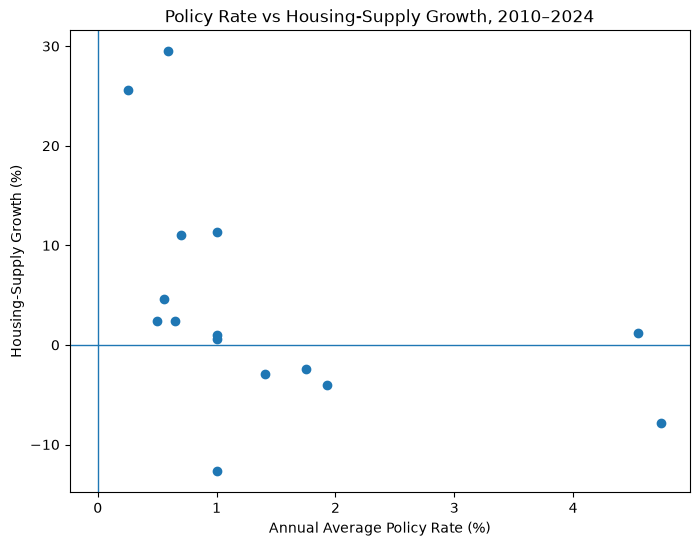

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    policy_housing["policy_rate"],
    policy_housing["housing_supply_growth_pct"]
)

plt.xlabel("Annual Average Policy Rate (%)")
plt.ylabel("Housing-Supply Growth (%)")
plt.title("Policy Rate vs Housing-Supply Growth, 2010–2024")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.show()

#### 6.2 Relationship between Policy Rate and Housing Prices

In [84]:
national_nhpi = (
    affordability
    .groupby("year")["nhpi"]
    .mean()
    .reset_index()
)

In [85]:
national_nhpi["nhpi_growth_pct"] = (
    national_nhpi["nhpi"]
    .pct_change()
    * 100
)

In [86]:
policy_nhpi = pd.merge(
    national_nhpi,
    policy_rate,
    on="year",
    how="inner"
)

In [87]:
policy_nhpi

,year,nhpi,nhpi_growth_pct,policy_rate
0,2010,92.019167,2.325948,0.590996
1,2011,93.982500,2.133613,1.000000
2,2012,95.420833,1.530427,1.000000
3,2013,96.976667,1.630496,1.000000
4,2014,97.734167,0.781116,1.000000
5,2015,98.247500,0.525234,0.646552
6,2016,99.323333,1.095024,0.500000
7,2017,101.030000,1.718294,0.698077
8,2018,101.842500,0.804217,1.404215
9,2019,101.914167,0.070370,1.750000


In [88]:
nhpi_policy_corr = policy_nhpi[
    ["policy_rate", "nhpi_growth_pct"]
].corr().loc[
    "policy_rate",
    "nhpi_growth_pct"
]

nhpi_policy_corr

np.float64(-0.29921061340816185)

#### The correlation coefficient **-0.3** indicates a very weak negative relationship between housing prices and the policy rate.

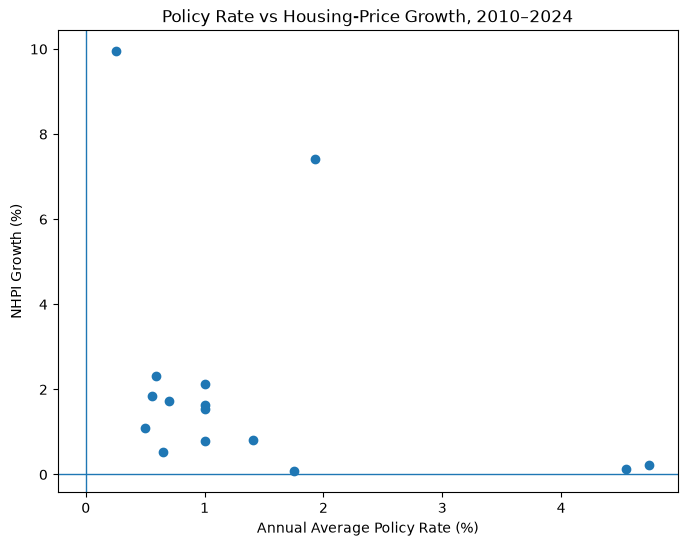

In [89]:
plt.figure(figsize=(8, 6))

plt.scatter(
    policy_nhpi["policy_rate"],
    policy_nhpi["nhpi_growth_pct"]
)

plt.xlabel("Annual Average Policy Rate (%)")
plt.ylabel("NHPI Growth (%)")
plt.title("Policy Rate vs Housing-Price Growth, 2010–2024")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.show()

# 7. Integrated Canadian Housing Market Analysis

This section brings together the national housing price, income, population, housing-supply, and monetary-policy indicators developed in the preceding analysis. The combined dataset provides a consistent framework for examining how these indicators evolved together between 2010 and 2024.

### 7.1 The Integrated Analysis Dataset

The national housing-market indicators are combined by year to create a single analytical dataset. This dataset contains the National Home Price Index, NHPI growth, the policy rate, housing starts, housing-supply growth, and population growth.

In [90]:
ca_housing_analysis_df = (
    policy_nhpi[
        ["year", "nhpi", "nhpi_growth_pct", "policy_rate"]
    ]
    .merge(
        policy_housing[
            ["year", "housing_starts_saar", "housing_supply_growth_pct"]
        ],
        on="year",
        how="inner"
    )
    .merge(
        national_growth[
            ["year", "population_growth_pct"]
        ],
        on="year",
        how="inner"
    )
)

In [91]:
ca_housing_analysis_df.shape

(15, 7)

In [92]:
ca_housing_analysis_df.isna().sum()

year                         0
nhpi                         0
nhpi_growth_pct              0
policy_rate                  0
housing_starts_saar          0
housing_supply_growth_pct    0
population_growth_pct        0
dtype: int64

In [93]:
ca_housing_analysis_df

,year,nhpi,nhpi_growth_pct,policy_rate,housing_starts_saar,housing_supply_growth_pct,population_growth_pct
0,2010,92.019167,2.325948,0.590996,191564.08,29.463181,1.047793
1,2011,93.982500,2.133613,1.000000,193387.24,0.951723,0.861416
2,2012,95.420833,1.530427,1.000000,215411.00,11.388425,0.892123
3,2013,96.976667,1.630496,1.000000,188031.41,-12.710395,0.776833
4,2014,97.734167,0.781116,1.000000,189107.67,0.572383,0.790754
5,2015,98.247500,0.525234,0.646552,193597.50,2.374219,0.652825
6,2016,99.323333,1.095024,0.500000,198168.24,2.360950,1.156553
7,2017,101.030000,1.718294,0.698077,219975.57,11.004453,1.106688
8,2018,101.842500,0.804217,1.404215,213571.19,-2.911405,1.189306
9,2019,101.914167,0.070370,1.750000,208496.68,-2.376027,1.277263


### 7.2 National Housing Price Trend

The National Home Price Index is examined over the 2010–2024 period to identify the long-term direction and major turning points in Canadian housing prices.

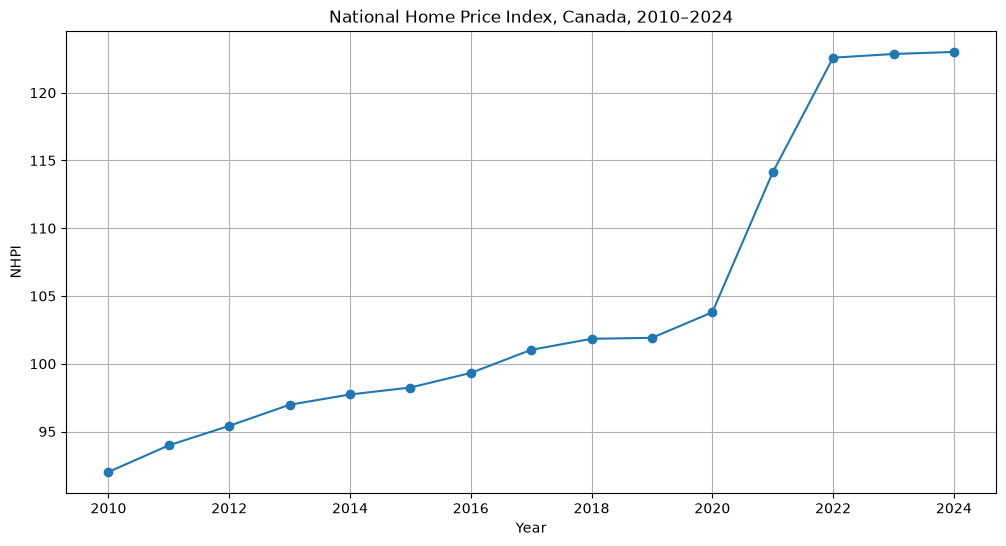

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["nhpi"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("NHPI")
plt.title("National Home Price Index, Canada, 2010–2024")
plt.grid(True)

plt.show()

Between 2010 and 2020, Canada’s National Home Price Index increased moderately from roughly 92 to 104 index points, marking a steady annual growth phase. The index then surged dramatically by over 18 points to peak near 122.5 in 2022, before plateauing and stabilizing around 123 points through 2024.

### 7.3 Annual Housing Price Growth

Annual NHPI growth is examined to identify periods of rapid housing-price appreciation and periods of weak or stagnant price growth.

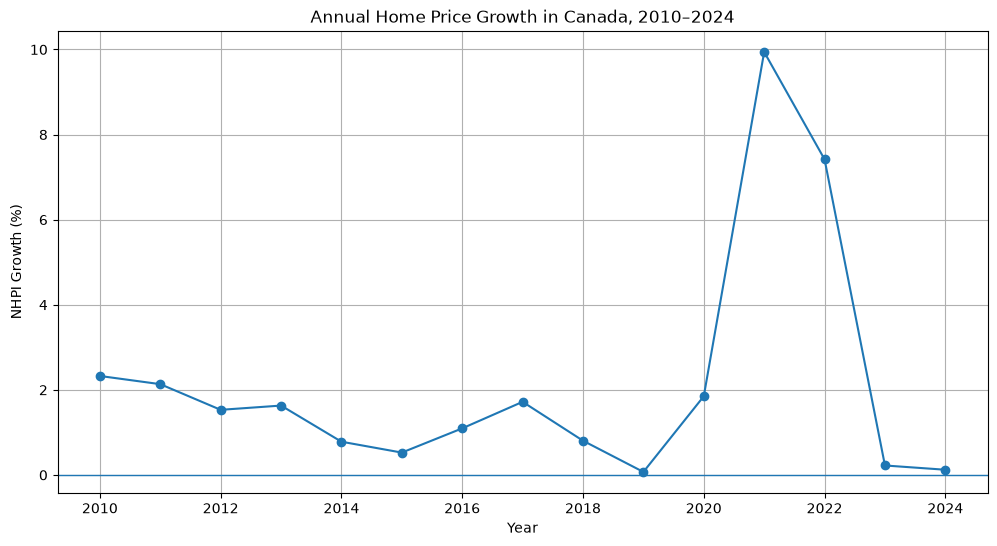

In [95]:
plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["nhpi_growth_pct"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("NHPI Growth (%)")
plt.title("Annual Home Price Growth in Canada, 2010–2024")
plt.grid(True)

plt.show()

From 2011 to 2020, Canada’s annual home price growth remained low and stable, fluctuating between roughly 0.1 percent and 2.1 percent Growth spiked dramatically to a peak of nearly 10 percent in 2021 before gradually tapering off through 2022 and dropping sharply back down near 0.1 percent by 2024.

### 7.4 Housing-Price Growth vs Income Growth

Housing-price growth is compared with income growth to evaluate whether household incomes kept pace with changes in housing prices. This comparison provides an important measure of affordability pressure.

In [96]:
national_income = (
    affordability
    .groupby("year")["income_growth_pct"]
    .mean()
    .reset_index()
)

In [97]:
ca_housing_analysis_df = ca_housing_analysis_df.merge(
    national_income,
    on="year",
    how="left"
)

In [98]:
ca_housing_analysis_df.columns

Index(['year', 'nhpi', 'nhpi_growth_pct', 'policy_rate', 'housing_starts_saar',
       'housing_supply_growth_pct', 'population_growth_pct',
       'income_growth_pct'],
      dtype='str')

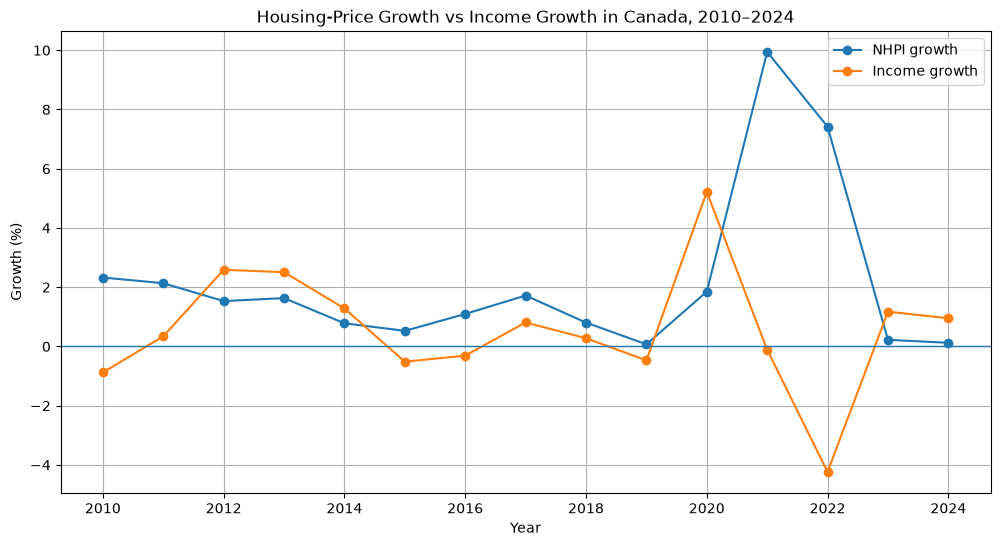

In [99]:
plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["nhpi_growth_pct"],
    marker="o",
    label="NHPI growth"
)

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["income_growth_pct"],
    marker="o",
    label="Income growth"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("Housing-Price Growth vs Income Growth in Canada, 2010–2024")
plt.legend()
plt.grid(True)

plt.show()

From 2011 to 2020, Canada’s housing market maintained relative price stability, with modest annual appreciation fluctuating between 0.1 and 2.1 percent. Pandemic-era macroeconomic shocks then fueled a period of rapid market overheating, pushing price growth to a peak of nearly 10.0 percent in 2021 before swift monetary tightening cooled the market back down to a near-stagnant 0.1 percent by 2024.

### 7.5 Population Growth vs Housing-Supply Growth

Population growth is compared with housing-supply growth to assess whether new housing construction expanded at a pace consistent with changes in population.

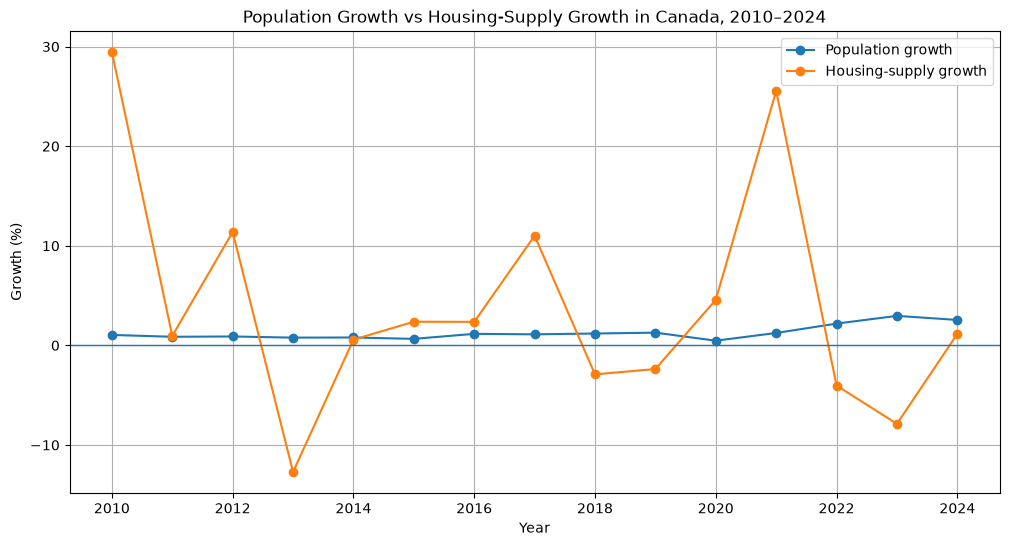

In [100]:
plt.figure(figsize=(12, 6))

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["population_growth_pct"],
    marker="o",
    label="Population growth"
)

plt.plot(
    ca_housing_analysis_df["year"],
    ca_housing_analysis_df["housing_supply_growth_pct"],
    marker="o",
    label="Housing-supply growth"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("Population Growth vs Housing-Supply Growth in Canada, 2010–2024")
plt.legend()
plt.grid(True)

plt.show()

Between 2010 and 2024, Canada’s population growth remained remarkably steady, creeping up gradually from less than one percent to about three percent. In stark contrast, housing-supply growth experienced wild volatility—swinging from a massive expansion peak of 25.6% in 2021 down to a contraction of -7.9% by 2023. This severe drop in home construction occurred precisely as population growth hit its highest levels, creating a sharp structural supply deficit before housing growth rebounded slightly to 1.1% in 2024.

### 7.6 Policy Rate vs Housing-Supply Growth

The relationship between the annual average policy rate and housing-supply growth is examined to assess whether changes in monetary conditions were associated with changes in housing construction.

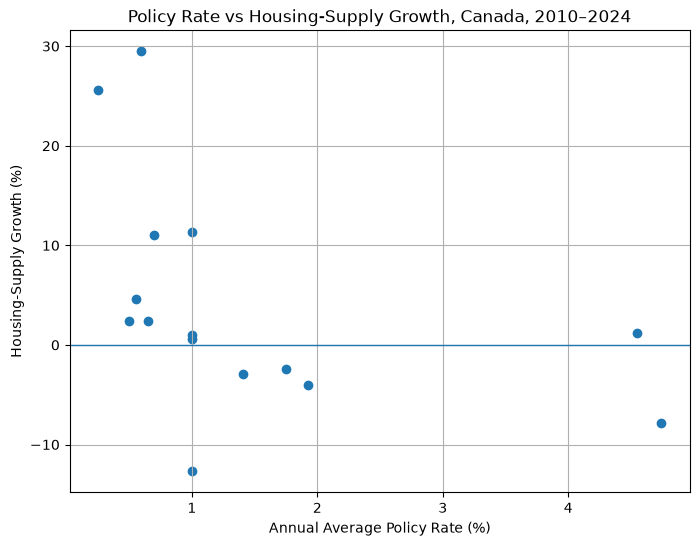

In [101]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ca_housing_analysis_df["policy_rate"],
    ca_housing_analysis_df["housing_supply_growth_pct"]
)

plt.xlabel("Annual Average Policy Rate (%)")
plt.ylabel("Housing-Supply Growth (%)")
plt.title("Policy Rate vs Housing-Supply Growth, Canada, 2010–2024")

plt.axhline(0, linewidth=1)
plt.grid(True)

plt.show()

# 8. Key Housing Market Indicators

This section quantifies the major changes in Canadian housing prices, income, population, and housing supply between 2010 and 2024. These calculations provide the headline metrics used to summarize the overall housing-market conditions.

### 8.1 Housing Price Change

The total change in the national NHPI between 2010 and 2024 is calculated to quantify the overall increase in Canadian housing prices.

In [102]:
nhpi_change = (
    (ca_housing_analysis_df["nhpi"].iloc[-1]
     / ca_housing_analysis_df["nhpi"].iloc[0]
     - 1)
    * 100
)

nhpi_change

np.float64(33.67504958206171)

In [103]:
canada_income = (
    affordability[
        affordability["region"] == "Canada"
    ][
        ["year", "median_after_tax_income"]
    ]
    .sort_values("year")
    .copy()
)

In [104]:
canada_income["income_growth_pct"] = (
    canada_income["median_after_tax_income"]
    .pct_change()
    * 100
)

In [105]:
canada_income = (
    income[
        income["region"] == "Canada"
    ][
        ["year", "median_after_tax_income"]
    ]
    .sort_values("year")
    .copy()
)

In [106]:
canada_income = (
    canada[
        ["year", "median_after_tax_income"]
    ]
    .sort_values("year")
    .copy()
)

In [107]:
canada_income = canada_income[
    canada_income["year"].between(2010, 2024)
].copy()

In [108]:
canada_income["income_growth_pct"] = (
    canada_income["median_after_tax_income"]
    .pct_change()
    * 100
)

In [109]:
canada_income

,year,median_after_tax_income,income_growth_pct
222,2010,67500.0,NaN
233,2011,67200.0,-0.444444
244,2012,69100.0,2.827381
255,2013,69500.0,0.578871
266,2014,71100.0,2.302158
277,2015,70900.0,-0.281294
288,2016,70900.0,0.000000
299,2017,72700.0,2.538787
310,2018,72700.0,0.000000
321,2019,72500.0,-0.275103


In [110]:
income_change = (
    (
        canada_income.loc[
            canada_income["year"] == 2024,
            "median_after_tax_income"
        ].iloc[0]
        /
        canada_income.loc[
            canada_income["year"] == 2010,
            "median_after_tax_income"
        ].iloc[0]
        - 1
    )
    * 100
)

income_change

np.float64(11.851851851851848)

### 8.3 Housing Price Growth vs Income Growth

The difference between NHPI growth and median after-tax income growth is calculated to quantify the extent to which housing prices increased faster than income.

In [111]:
affordability_difference = nhpi_change - income_change

affordability_difference

np.float64(21.823197730209863)

In [112]:
relative_growth = nhpi_change / income_change

relative_growth

np.float64(2.8413323084864577)

### 8.4 Population Change

The total population change between 2010 and 2024 is calculated to provide context for the changing demand for housing.

In [113]:
canada_population = (
    canada[
        ["year", "population"]
    ]
    .sort_values("year")
    .copy()
)

In [114]:
canada_population = canada_population[
    canada_population["year"].between(2010, 2024)
].copy()

In [115]:
canada_population

,year,population
222,2010,34132531
233,2011,34457713
244,2012,34834973
255,2013,35209597
266,2014,35555305
277,2015,35823591
288,2016,36257421
299,2017,36722075
310,2018,37259485
321,2019,37828162


In [116]:
population_change = (
    (
        canada_population.loc[
            canada_population["year"] == 2024,
            "population"
        ].iloc[0]
        /
        canada_population.loc[
            canada_population["year"] == 2010,
            "population"
        ].iloc[0]
        - 1
    )
    * 100
)

population_change

np.float64(21.567697396949548)

### 8.5 Housing Supply Change

The change in housing starts between 2010 and 2024 is calculated to measure the overall change in housing construction activity.

In [117]:
housing_supply_change = (
    (
        ca_housing_analysis_df.loc[
            ca_housing_analysis_df["year"] == 2024,
            "housing_starts_saar"
        ].iloc[0]
        /
        ca_housing_analysis_df.loc[
            ca_housing_analysis_df["year"] == 2010,
            "housing_starts_saar"
        ].iloc[0]
        - 1
    )
    * 100
)

housing_supply_change

np.float64(27.791791655304053)

# 9. Regional Supply-Demand Analysis


The supply-demand growth gap is examined across provinces to determine whether housing-supply growth generally exceeded or lagged population growth at the regional level.

### 9.1 Regional Supply Gap (2010-2024)

In [118]:
housing_demand_supply_2010_2024 = housing_demand_supply[
    housing_demand_supply["year"].between(2010, 2024)
].copy()

In [119]:
housing_demand_supply_2010_2024.head()

,year,region,population,population_growth_pct,housing_starts_saar,housing_supply_growth_pct,supply_demand_growth_gap_pct
20,2010,Alberta,3747235,1.432389,27378.75,36.745586,35.313197
21,2011,Alberta,3805071,1.543431,25543.17,-6.704397,-8.247828
22,2012,Alberta,3897746,2.435566,33285.00,30.308807,27.873241
23,2013,Alberta,4008421,2.839462,36111.83,8.492805,5.653343
24,2014,Alberta,4103702,2.377021,40563.67,12.327927,9.950906


In [120]:
regional_supply_gap = (
    housing_demand_supply_2010_2024
    .groupby("region")["supply_demand_growth_gap_pct"]
    .mean()
    .sort_values(ascending=False)
)

regional_supply_gap

region
British Columbia             7.116070
Alberta                      5.882666
Nova Scotia                  5.552436
New Brunswick                4.460717
Prince Edward Island         4.057875
Manitoba                     3.698980
Saskatchewan                 3.156563
Ontario                      2.218746
Quebec                       1.137467
Newfoundland and Labrador    0.376663
Name: supply_demand_growth_gap_pct, dtype: float64

In [121]:
positive_gap = (regional_supply_gap > 0).sum()
negative_gap = (regional_supply_gap < 0).sum()

positive_gap, negative_gap

(np.int64(10), np.int64(0))

# 10. Policy Rate and Housing Market Relationships

The relationship between monetary policy and Canadian housing-market outcomes is examined using scatter plots and correlation coefficients. The analysis focuses on the association between the policy rate and both housing-price growth and housing-supply growth.

### 10.1 Policy Rate vs NHPI Growth

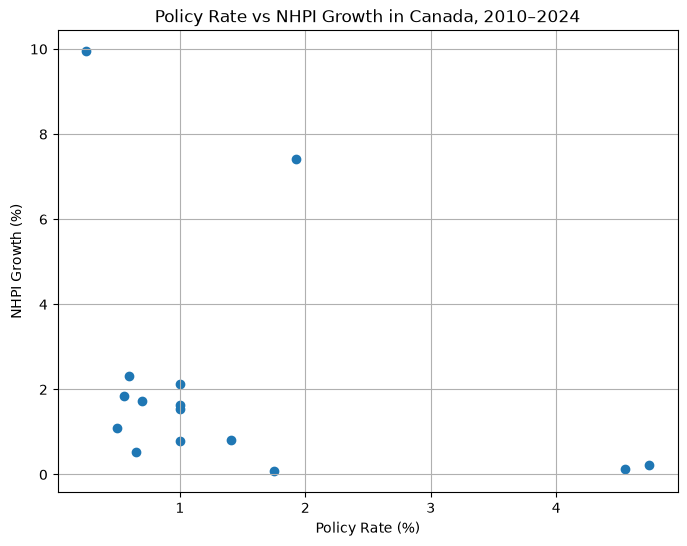

In [122]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ca_housing_analysis_df["policy_rate"],
    ca_housing_analysis_df["nhpi_growth_pct"]
)

plt.xlabel("Policy Rate (%)")
plt.ylabel("NHPI Growth (%)")
plt.title("Policy Rate vs NHPI Growth in Canada, 2010–2024")
plt.grid(True)

plt.show()

### 10.2 Policy Rate vs Housing-Supply Growth

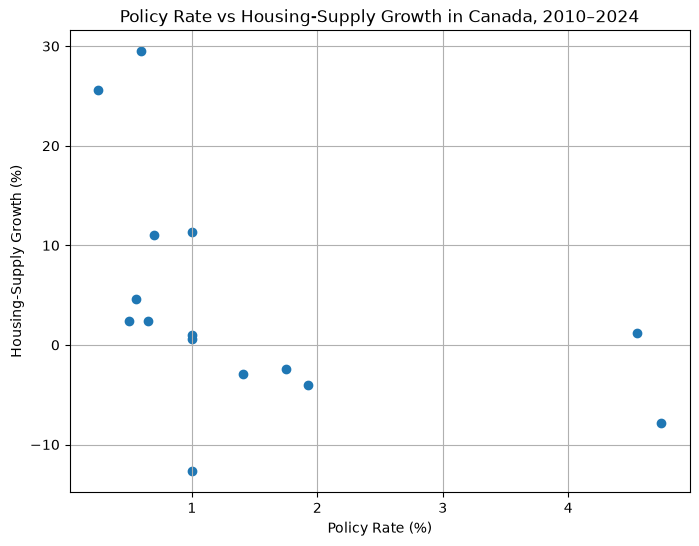

In [123]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ca_housing_analysis_df["policy_rate"],
    ca_housing_analysis_df["housing_supply_growth_pct"]
)

plt.xlabel("Policy Rate (%)")
plt.ylabel("Housing-Supply Growth (%)")
plt.title("Policy Rate vs Housing-Supply Growth in Canada, 2010–2024")
plt.grid(True)

plt.show()

### 10.3 Interpretation

Both housing-price growth and housing-supply growth show negative associations with the policy rate.

The correlation between the policy rate and NHPI growth is approximately -0.30, while the correlation between the policy rate and housing-supply growth is approximately -0.43.

The stronger negative association with housing-supply growth suggests that housing construction was more closely associated with changes in monetary conditions than annual housing-price growth during the study period.

However, these correlations measure association rather than causation. Other factors, including economic conditions, construction costs, household demand, credit conditions, and market expectations, may also influence housing outcomes.

In [124]:
supply_population_difference = (
    housing_supply_change - population_change
)

supply_population_difference

np.float64(6.224094258354505)

# 11. Final Key Findings

The key findings table consolidates the principal quantitative results from the analysis into a single summary for interpretation and reporting.

In [125]:
key_findings = pd.DataFrame({
    "Metric": [
        "NHPI change, 2010–2024",
        "Median after-tax income change, 2010–2024",
        "NHPI growth relative to income growth",
        "Population change, 2010–2024",
        "Housing starts change, 2010–2024",
        "Housing supply growth relative to population",
        "Provinces with positive supply-demand gap",
        "Provinces with negative supply-demand gap",
        "Policy rate vs housing-supply growth",
        "Policy rate vs NHPI growth"
    ],
    "Result": [
        nhpi_change,
        income_change,
        relative_growth,
        population_change,
        housing_supply_change,
        supply_population_difference,
        positive_gap,
        negative_gap,
        -0.431322,
        -0.30059176893045997
    ]
})

key_findings

,Metric,Result
0,"NHPI change, 2010–2024",33.675050
1,"Median after-tax income change, 2010–2024",11.851852
2,NHPI growth relative to income growth,2.841332
3,"Population change, 2010–2024",21.567697
4,"Housing starts change, 2010–2024",27.791792
5,Housing supply growth relative to population,6.224094
6,Provinces with positive supply-demand gap,10.000000
7,Provinces with negative supply-demand gap,0.000000
8,Policy rate vs housing-supply growth,-0.431322
9,Policy rate vs NHPI growth,-0.300592


In [126]:
key_findings.round(2)

,Metric,Result
0,"NHPI change, 2010–2024",33.68
1,"Median after-tax income change, 2010–2024",11.85
2,NHPI growth relative to income growth,2.84
3,"Population change, 2010–2024",21.57
4,"Housing starts change, 2010–2024",27.79
5,Housing supply growth relative to population,6.22
6,Provinces with positive supply-demand gap,10.00
7,Provinces with negative supply-demand gap,0.00
8,Policy rate vs housing-supply growth,-0.43
9,Policy rate vs NHPI growth,-0.30


### 11.1 Highest and Lowest Growth Years

The strongest and weakest annual growth observations are identified for housing prices, population, and housing supply to highlight the major periods of change during the study period.

In [127]:
nhpi_highest = (
    ca_housing_analysis_df
    .nlargest(3, "nhpi_growth_pct")
    [["year", "nhpi_growth_pct"]]
)

nhpi_lowest = (
    ca_housing_analysis_df
    .nsmallest(3, "nhpi_growth_pct")
    [["year", "nhpi_growth_pct"]]
)

nhpi_highest, nhpi_lowest

(    year  nhpi_growth_pct
 11  2021         9.942276
 12  2022         7.417685
 0   2010         2.325948,
     year  nhpi_growth_pct
 9   2019         0.070370
 14  2024         0.122093
 13  2023         0.222296)

In [128]:
population_highest = (
    ca_housing_analysis_df
    .nlargest(3, "population_growth_pct")
    [["year", "population_growth_pct"]]
)

population_lowest = (
    ca_housing_analysis_df
    .nsmallest(3, "population_growth_pct")
    [["year", "population_growth_pct"]]
)

population_highest, population_lowest

(    year  population_growth_pct
 13  2023               2.961572
 14  2024               2.552916
 12  2022               2.185689,
     year  population_growth_pct
 10  2020               0.470378
 5   2015               0.652825
 3   2013               0.776833)

In [129]:
housing_supply_highest = (
    ca_housing_analysis_df
    .nlargest(3, "housing_supply_growth_pct")
    [["year", "housing_supply_growth_pct"]]
)

housing_supply_lowest = (
    ca_housing_analysis_df
    .nsmallest(3, "housing_supply_growth_pct")
    [["year", "housing_supply_growth_pct"]]
)

housing_supply_highest, housing_supply_lowest

(    year  housing_supply_growth_pct
 0   2010                  29.463181
 11  2021                  25.560188
 2   2012                  11.388425,
     year  housing_supply_growth_pct
 3   2013                 -12.710395
 13  2023                  -7.882553
 12  2022                  -4.034702)

# 12. Recent Housing Market Comparison

### 12.1 Housing Market Growth Indicators

In [130]:
ca_housing_analysis_df["year"] = (
    ca_housing_analysis_df["year"].astype(int)
)

In [131]:
recent_period = ca_housing_analysis_df[
    ca_housing_analysis_df["year"].between(2020, 2024)
].copy()

recent_period

,year,nhpi,nhpi_growth_pct,policy_rate,housing_starts_saar,housing_supply_growth_pct,population_growth_pct,income_growth_pct
10,2020,103.799167,1.849596,0.556513,218026.17,4.570572,0.470378,5.216578
11,2021,114.119167,9.942276,0.250000,273754.07,25.560188,1.244187,-0.110995
12,2022,122.584167,7.417685,1.929688,262708.91,-4.034702,2.185689,-4.238639
13,2023,122.856667,0.222296,4.743243,242000.74,-7.882553,2.961572,1.171601
14,2024,123.006667,0.122093,4.546935,244803.17,1.158025,2.552916,0.951799


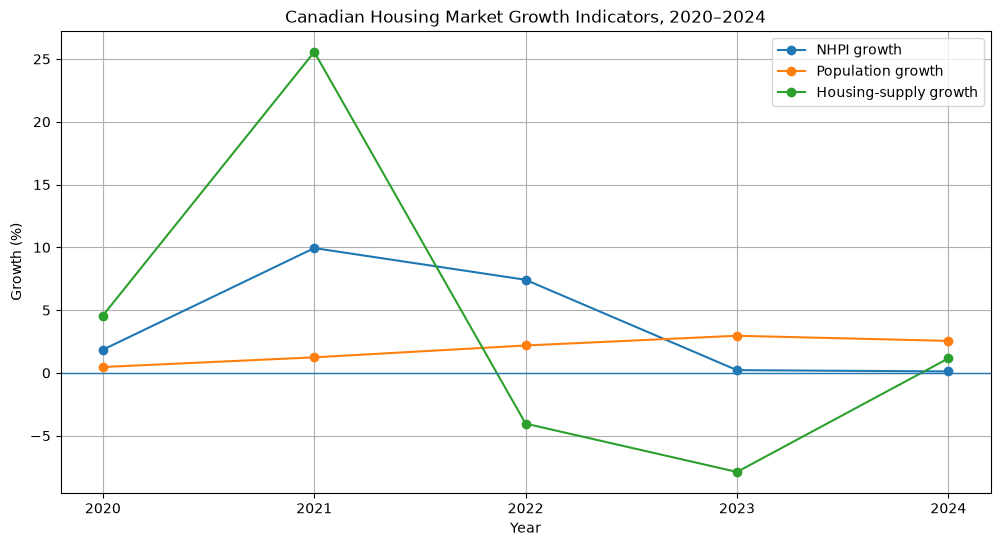

In [132]:
plt.figure(figsize=(12, 6))

plt.plot(
    recent_period["year"],
    recent_period["nhpi_growth_pct"],
    marker="o",
    label="NHPI growth"
)

plt.plot(
    recent_period["year"],
    recent_period["population_growth_pct"],
    marker="o",
    label="Population growth"
)

plt.plot(
    recent_period["year"],
    recent_period["housing_supply_growth_pct"],
    marker="o",
    label="Housing-supply growth"
)

plt.xticks(recent_period["year"])

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.title("Canadian Housing Market Growth Indicators, 2020–2024")
plt.legend()
plt.grid(True)

plt.show()

Between 2020 and 2024, Canada’s housing market went from a pandemic-driven boom to a supply-demand squeeze and eventual price freeze.

In 2021, low interest rates pushed homebuilder supply growth to a peak of 25.6% and price appreciation (NHPI) to nearly 10.0%, while population growth was low at 1.2%. As rate hikes hit, home construction plummeted to -7.9% by 2023—right when population growth surged to a 3.0% peak, creating a massive supply gap. By 2024, high borrowing costs flattened price growth to a near-standstill at 0.1%, while construction began a modest recovery to 1.1%.